In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import scienceplots

import time
import math
from bisect import bisect
import os
import sys
import random
from functools import partial
from decimal import Decimal
from collections import Counter
import numpy as np
import scipy.io as sio
import pysindy as ps
from tqdm import trange

sys.path.insert(0, '../')
from utils import *
from solvel0 import solvel0, MIOSR
from best_subset import backward_refinement, brute_force_all_subsets, brute_force
from UBIC import *
from bayesian_model_evidence import log_evidence

from skimage.restoration import estimate_sigma
import bm3d
from kneed import KneeLocator

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn import covariance
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoLarsIC, lars_path, ElasticNet, ARDRegression
from abess import LinearRegression as AbessLinearRegression
from knockpy import KnockoffFilter, knockoff_stats, knockoffs
from knockpy.utilities import estimate_covariance
from scipy import stats
from statsmodels.stats.multitest import multipletests
from c2st.check import c2st # https://github.com/psteinb/c2st

from mbic import mbic, mbic2, ebic

from rdata import read_rds
from selective_inference import forward_stop_rule, sfs_si, stepwise_selective_inference, subset_fdr
import fpsample
from dppy.finite_dpps import FiniteDPP

from si4pipeline import (
                        construct_pipelines, 
                        extract_features, 
                        initialize_dataset, 
                        intersection, 
                        lasso, 
                        marginal_screening, 
                        stepwise_feature_selection, 
                        union, 
                        PipelineManager
                        )

from pymcdm import weights as obj_w
from compromise_programming import optimal_decision, compromise_programming, mcdm
from pyRankMCDA.algorithm import rank_aggregation

In [2]:
data_path = "../Datasets/"
data = sio.loadmat(os.path.join(data_path, "burgers.mat"))
u_clean = (data['usol']).real; u = u_clean.copy()
x = (data['x'][0]).real
t = (data['t'][:,0]).real
xt = np.array([x, t], dtype=object)
dt = t[1]-t[0]; dx = x[2]-x[1]

In [3]:
np.random.seed(0)
noise_type = "gaussian"
noise_lv = float(50)
print("Noise level:", noise_lv)
noise = 0.01*np.abs(noise_lv)*(u.std())*np.random.randn(u.shape[0],u.shape[1])
u = u + noise

Noise level: 50.0


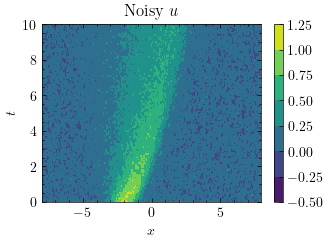

In [4]:
X, T = np.meshgrid(x, t)
with plt.style.context('science'):
    contour = plt.contourf(X, T, u.T, cmap='viridis')
    plt.colorbar(contour)
    plt.xlabel('$x$')
    plt.ylabel('$t$')
    plt.title('Noisy $u$')
    plt.show()

In [5]:
np.random.seed(0)
fake_noise = np.random.normal(loc=0.0, scale=estimate_sigma(u), size=u.shape)
sigmas = estimate_sigma(u+fake_noise)*np.arange(0.1, 2., 0.1)
est_sigma = sigmas[np.argmin([((u-bm3d.bm3d(u+fake_noise, sigma_psd=sigma, stage_arg=bm3d.BM3DStages.ALL_STAGES, blockmatches=(False, False)))**2).mean() \
                              for sigma in sigmas])]
u = bm3d.bm3d(u, sigma_psd=est_sigma, 
                  stage_arg=bm3d.BM3DStages.ALL_STAGES, 
                  blockmatches=(False, False))

### weakident

In [6]:
# from weakident_python.weakindent_model import weak_ident

# # Ground truth
# true_coefficients = np.array([np.array([[2, 1, 0, -0.5], [1, 2, 0, 0.1]])])
# # Hyperparameters
# config = {'true_coefficients': true_coefficients, 
#           'max_dx': 6, 'max_poly': 6, 'use_cross_der': False, 'skip_x': 7, 'skip_t': 3, 'tau': 0.05}

# # Sparse regression
# np.random.seed(99)
# X_pre, y_pre, c_pred, dictionary_list, lhs_feature, rhs_feature = weak_ident(np.expand_dims(u, 0), xt, **config)
# feature_names = rhs_feature

### ps.WeakPDELibrary

In [7]:
n_poly = 6
n_derivatives = 6
n_weak = 2000
fit_intercept = False
include_bias = True
if include_bias:
    fit_intercept = False

### Cache (n_weak = 10000) ###
# X_pre = np.load("../Cache/X_pre_burgers_noise50.npy")
# y_pre = np.load("../Cache/y_pre_burgers_noise50.npy")
# u_pre = y_pre.copy()
# feature_names = np.load("../Cache/feature_names_burgers.npy")
# fsInf = read_rds("../R/R_data/fsInf_screening_burgers_noise50.rds")

function_library = ps.PolynomialLibrary(degree=n_poly, include_bias=False)

weak_lib = ps.WeakPDELibrary(
    function_library=function_library,
    derivative_order=n_derivatives,
    spatiotemporal_grid=np.asarray([*np.meshgrid(x, t)]).T,
    include_bias=include_bias,
    diff_kwargs={"is_uniform":True},
    K=n_weak
)

X_pre = np.array(weak_lib.fit_transform(np.expand_dims(u, -1)))
y_pre = weak_lib.convert_u_dot_integral(np.expand_dims(u, -1))
feature_names = np.array(weak_lib.get_feature_names())

# The system of linear equations
u_pre = y_pre.copy()
X_pre_top = StandardScaler(with_std=True).fit_transform(X_pre)
y_pre = StandardScaler(with_std=False).fit_transform(u_pre)

true_coefficients = np.zeros(len(feature_names))
true_coefficients[[8, 13]] = [0.1, -1]

In [8]:
# This wsindy package is from https://github.com/Pongpisit-Thanasutives/WSINDy.
from wsindy import WeakSINDy

coords = [x, t]

# Convenience specification: maximum spatial derivative, temporal derivative
# (the left-hand side, default 1) and monomial power. The candidate library is 
# generated automatically from the data's dimensions.
model = WeakSINDy(
    max_spatial_derivative=n_derivatives,   # u_x ... u_xxxx
    max_temporal_derivative=1,  # u_t on the left-hand side
    max_power=n_poly,                # monomials up to u^2
)
model.fit(u, coords)
model.print()

candidate_library = model.library.Theta.cpu().numpy()
feature_names = model.library.get_feature_names()
weak_lhs = model.library.weak_lhs.cpu().numpy().reshape(-1, 1)

HYPER-PARAMETERS
m = [65, 24]
p = [7, 10]
s = [5, 2]
[yx, yt] = [1.333, 0.417]
yu = 1.303
Aux. scales = []

LIBRARY
Num. query points = 702
Num. terms = 43
cond(G) = 4.616e+06

RESULTS
PDE: u_{t} = - 0.33(u^6) - 0.29(u)_{x} - 0.72(u)_{xxx} + 1.16(u^2)_{xxx} - 0.13(u)_{xxxx} - 0.23(u)_{xxxxx} + 0.36(u^2)_{xxxxx} - 0.04(u)_{xxxxxx}
Nonzero terms = 8
Rel. L2 error = 0.145
R^2 = 0.979
Lambda = 3.393e-02
Loss = 0.324


In [9]:
# model = WeakSINDy(
#     derivative_orders = [[0, 1], [1, 0], [2, 0]],
#     function_powers = [[0], [1], [2]]
# )
model = WeakSINDy(
    max_spatial_derivative=2,   # u_x ... u_xxxx
    max_temporal_derivative=1,  # u_t on the left-hand side
    max_power=2,                # monomials up to u^2
)
model.fit(u, coords)
model.print()

wsindy_coefficients = model.coefficients()[np.nonzero(model.coefficients())]
wsindy_coefficients[0] *= 2
wsindy_coefficients

HYPER-PARAMETERS
m = [65, 24]
p = [7, 10]
s = [5, 2]
[yx, yt] = [0.921, 0.417]
yu = 1.352
Aux. scales = []

LIBRARY
Num. query points = 702
Num. terms = 7
cond(G) = 1.110e+02

RESULTS
PDE: u_{t} = - 0.50(u^2)_{x} + 0.11(u)_{xx}
Nonzero terms = 2
Rel. L2 error = 0.099
R^2 = 0.990
Lambda = 4.095e-02
Loss = 0.314


tensor([[-1.0033],
        [ 0.1064]], dtype=torch.float64)